# Words

In [1]:
import sys
import os
sys.path.append(os.path.abspath("..\\.."))
from Modules.latentspacemodel import *
from Modules.inference import *
from Modules.afteranalyses import *

## Network

In [2]:

from string import ascii_lowercase as lowercase
def generate_graph(words):
    G = nx.Graph(name="words")
    lookup = {c: lowercase.index(c) for c in lowercase}

    def edit_distance_one(word):
        for i in range(len(word)):
            left, c, right = word[0:i], word[i], word[i + 1:]
            j = lookup[c]
            for cc in lowercase[j + 1:]:
                yield left + cc + right

    candgen = (
        (word, cand)
        for word in sorted(words)
        for cand in edit_distance_one(word)
        if cand in words
    )

    G.add_nodes_from(words)

    for word, cand in candgen:
        G.add_edge(word, cand)

    return G


def words_graph():
    words = set()
    with open("C://Users//carlo//OneDrive//Documents//Latentspacemodels_Networks//Complement//Examples//Words//words_dat.txt", "r", encoding="utf-8") as fh:
        for line in fh:
            if line.startswith("*"):
                continue
            w = line[0:5]
            words.add(w.strip())
    return generate_graph(words)


print("Complete graph")
G = words_graph()
print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())
print("Connected components:", nx.number_connected_components(G))

# Giant component
print("Giant component")
largest_cc = max(nx.connected_components(G), key=len)
G = G.subgraph(largest_cc).copy()
print("Nodes in giant component:", G.number_of_nodes())
print("Edges in giant component:", G.number_of_edges())


Complete graph
Number of nodes: 5757
Number of edges: 14135
Connected components: 853
Giant component
Nodes in giant component: 4493
Edges in giant component: 13619


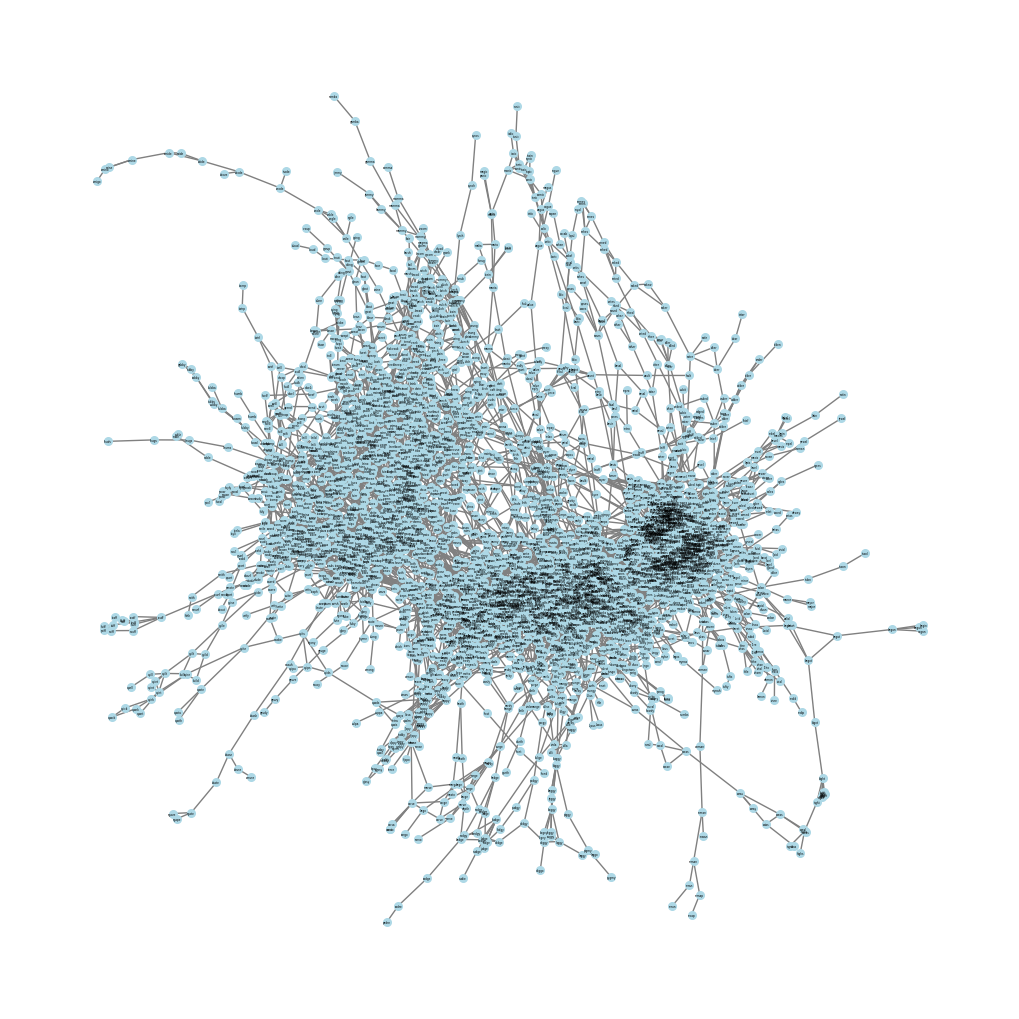

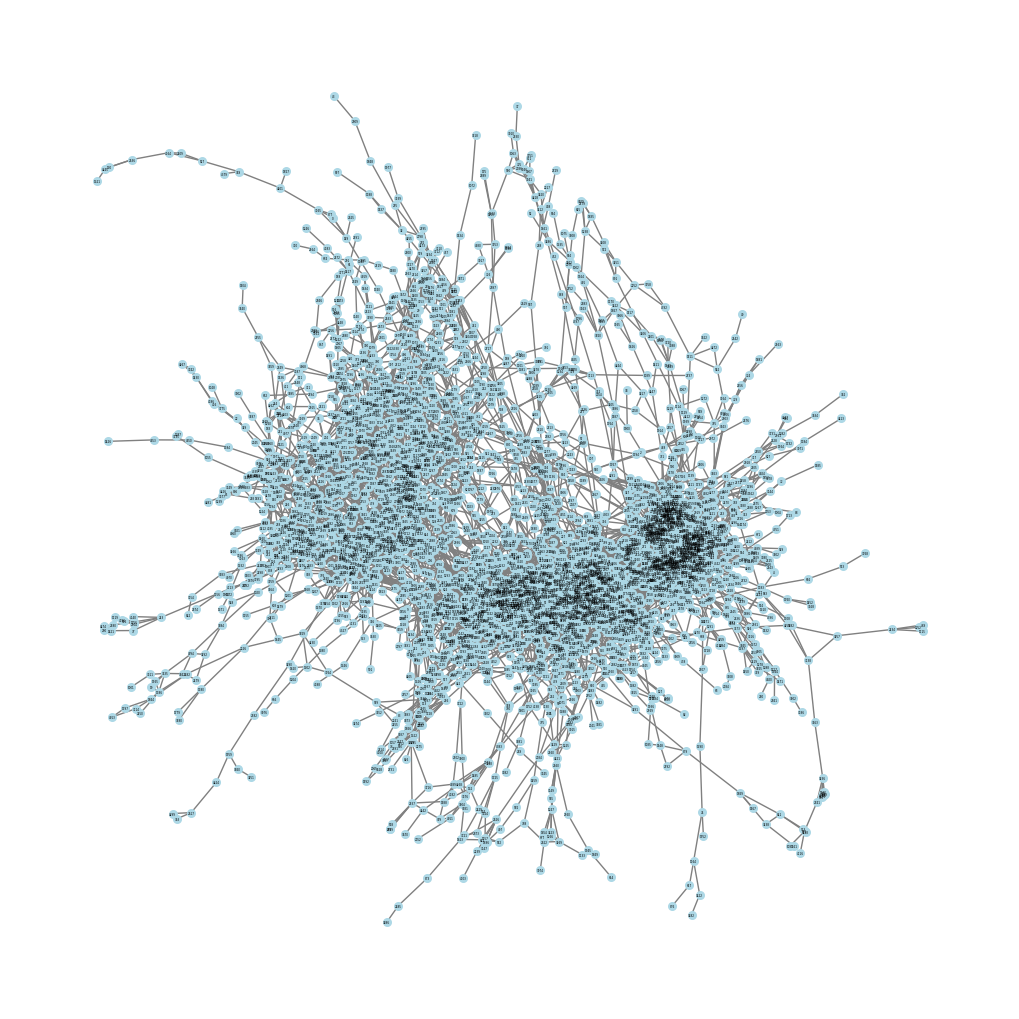

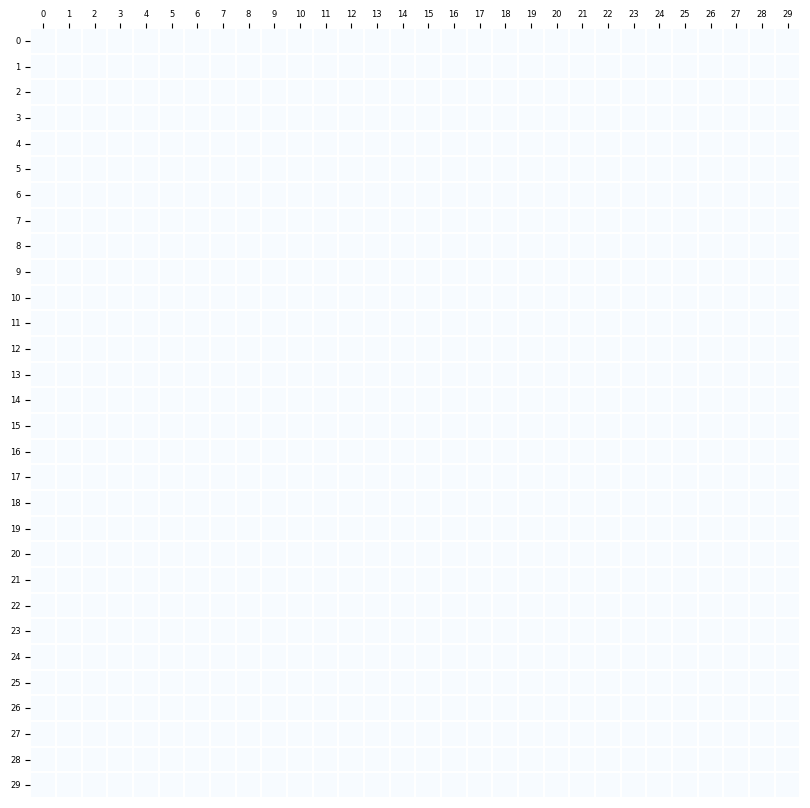

In [3]:

pos = nx.spring_layout(G, seed=80)
plt.figure(figsize=(10,10))
nx.draw(G, pos=pos, with_labels=True, node_color="lightblue", edge_color="gray", node_size=30, font_size=2)
plt.show()

node_mapping = {node: i for i, node in enumerate(G.nodes())}
G = nx.relabel_nodes(G, node_mapping)
pos_relabel = {node_mapping[k]: v for k, v in pos.items()}
plt.figure(figsize=(10,10))
nx.draw(G,pos=pos_relabel, with_labels=True, node_color="lightblue", edge_color="gray", node_size=30, font_size=2)
plt.show()

inverse_mapping = {v: k for k, v in node_mapping.items()}

Y = nx.to_numpy_array(G, dtype=int)
Y = (Y > 0).astype(int)
n = Y.shape[0]
plt.figure(figsize=(10,10))
sns.heatmap(Y[0:30,0:30], annot=False, cmap="Blues", cbar=False, square=True, linewidths=0.1, linecolor="white")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.gca().xaxis.tick_top()
plt.gca().tick_params(top=True, bottom=False, labeltop=True, labelbottom=False, labelsize=6)
plt.show()

In [ ]:
seed_MAP = 42
diam = 10.0
n = Y.shape[0]
lr_MAP = 1e-2
n_starts_MAP = 1
n_iter_MAP = 25000
n_sim_iv = 2500
n_iter_cv = 1000
n_folds_cv = 5

## Models over $\mathbb{R}^d$

### Model $\mathbb{R^1}$

#### Without weights

In [ ]:
geometry = EuclideanGeometry(d=1, D=diam)
model = LatentSpaceModel(Y=Y, geometry=geometry, fixed_params={"xi": np.ones(n)})
inference = MAPInference(model, lr=lr_MAP)
result = inference.fit_multi_start(n_starts=n_starts_MAP, n_iter=n_iter_MAP, verbose=True, use_tqdm=True)

analysis = ModelAnalysis(model,inference_key="MAP")
analysis.plot_logposterior_trace()
analysis.compare_with_adjacency(analysis.P,title="Probability matrix")
analysis.internal_validation(n_sim=n_sim_iv)
analysis.plot_ppc_distributions()
analysis.laplacian_validation() 
analysis.binary_prediction_metrics()
analysis.plot_roc_curve()
analysis.plot_precision_recall_curve()
analysis.confusion_matrix(threshold=0.5)
analysis.cross_validation(n_folds=n_folds_cv, seed=seed_MAP, n_iter=n_iter_cv, lr=lr_MAP)
print(analysis.cross_validation_summary())

model.save("Words_R1_c.pkl")

#### With weights

In [ ]:
geometry = EuclideanGeometry(d=1, D=diam)
alpha0 = model.inferred["MAP"]["final_params"]["alpha0"]
Z = model.inferred["MAP"]["final_params"]["Z"]
model = LatentSpaceModel(Y=Y, geometry=geometry, fixed_params={"Z": Z, "alpha0": alpha0})
inference = MAPInference(model, lr=lr_MAP)
result = inference.fit_multi_start(n_starts=n_starts_MAP, n_iter=n_iter_MAP, verbose=True, use_tqdm=True)

analysis = ModelAnalysis(model,inference_key="MAP")
analysis.plot_logposterior_trace()
analysis.compare_with_adjacency(analysis.P,title="Probability matrix")
analysis.internal_validation(n_sim=n_sim_iv)
analysis.plot_ppc_distributions()
analysis.laplacian_validation() 
analysis.binary_prediction_metrics()
analysis.plot_roc_curve()
analysis.plot_precision_recall_curve()
analysis.confusion_matrix(threshold=0.5)
analysis.cross_validation(n_folds=n_folds_cv, seed=seed_MAP, n_iter=n_iter_cv, lr=lr_MAP)
print(analysis.cross_validation_summary())

model.save("Words_R1_p.pkl")

### Model $\mathbb{R}^2$

#### Without weigths

In [ ]:
geometry = EuclideanGeometry(d=2, D=diam)
model = LatentSpaceModel(Y=Y, geometry=geometry, fixed_params={"xi": np.ones(n)})
inference = MAPInference(model, lr=lr_MAP)
result = inference.fit_multi_start(n_starts=n_starts_MAP, n_iter=n_iter_MAP, verbose=True, use_tqdm=True)

analysis = ModelAnalysis(model,inference_key="MAP")
analysis.plot_logposterior_trace()
analysis.compare_with_adjacency(analysis.P,title="Probability matrix")
analysis.internal_validation(n_sim=n_sim_iv)
analysis.plot_ppc_distributions()
analysis.laplacian_validation() 
analysis.binary_prediction_metrics()
analysis.plot_roc_curve()
analysis.plot_precision_recall_curve()
analysis.confusion_matrix(threshold=0.5)
analysis.cross_validation(n_folds=n_folds_cv, seed=seed_MAP, n_iter=n_iter_cv, lr=lr_MAP)
print(analysis.cross_validation_summary())

model.save("Words_R2_c.pkl")

#### With weights

In [ ]:
geometry = EuclideanGeometry(d=2, D = diam)
alpha0 = model.inferred["MAP"]["final_params"]["alpha0"]
Z = model.inferred["MAP"]["final_params"]["Z"]
model = LatentSpaceModel(Y=Y, geometry=geometry, fixed_params={"Z": Z, "alpha0": alpha0})
inference = MAPInference(model, lr=lr_MAP)
result = inference.fit_multi_start(n_starts=n_starts_MAP, n_iter=n_iter_MAP, verbose=True, use_tqdm=True)

analysis = ModelAnalysis(model,inference_key="MAP")
analysis.plot_logposterior_trace()
analysis.compare_with_adjacency(analysis.P,title="Probability matrix")
analysis.internal_validation(n_sim=n_sim_iv)
analysis.plot_ppc_distributions()
analysis.laplacian_validation() 
analysis.binary_prediction_metrics()
analysis.plot_roc_curve()
analysis.plot_precision_recall_curve()
analysis.confusion_matrix(threshold=0.5)
analysis.cross_validation(n_folds=n_folds_cv, seed=seed_MAP, n_iter=n_iter_cv, lr=lr_MAP)
print(analysis.cross_validation_summary())

model.save("Words_R2_p.pkl")

### Model $\mathbb{R}^3$

#### Without weights

In [ ]:
geometry = EuclideanGeometry(d=3, D=diam)
model = LatentSpaceModel(Y=Y, geometry=geometry, fixed_params={"xi": np.ones(n)})
inference = MAPInference(model, lr=lr_MAP)
result = inference.fit_multi_start(n_starts=n_starts_MAP, n_iter=n_iter_MAP, verbose=True, use_tqdm=True)

analysis = ModelAnalysis(model,inference_key="MAP")
analysis.plot_logposterior_trace()
analysis.compare_with_adjacency(analysis.P,title="Probability matrix")
analysis.internal_validation(n_sim=n_sim_iv)
analysis.plot_ppc_distributions()
analysis.laplacian_validation() 
analysis.binary_prediction_metrics()
analysis.plot_roc_curve()
analysis.plot_precision_recall_curve()
analysis.confusion_matrix(threshold=0.5)
analysis.cross_validation(n_folds=n_folds_cv, seed=seed_MAP, n_iter=n_iter_cv, lr=lr_MAP)
print(analysis.cross_validation_summary())

model.save("Words_R3_c.pkl")

#### With weights

In [ ]:
geometry = EuclideanGeometry(d=3, D = diam)
alpha0 = model.inferred["MAP"]["final_params"]["alpha0"]
Z = model.inferred["MAP"]["final_params"]["Z"]
model = LatentSpaceModel(Y=Y, geometry=geometry, fixed_params={"Z": Z, "alpha0": alpha0})
inference = MAPInference(model, lr=lr_MAP)
result = inference.fit_multi_start(n_starts=n_starts_MAP, n_iter=n_iter_MAP, verbose=True, use_tqdm=True)

analysis = ModelAnalysis(model,inference_key="MAP")
analysis.plot_logposterior_trace()
analysis.compare_with_adjacency(analysis.P,title="Probability matrix")
analysis.internal_validation(n_sim=n_sim_iv)
analysis.plot_ppc_distributions()
analysis.laplacian_validation() 
analysis.binary_prediction_metrics()
analysis.plot_roc_curve()
analysis.plot_precision_recall_curve()
analysis.confusion_matrix(threshold=0.5)
analysis.cross_validation(n_folds=n_folds_cv, seed=seed_MAP, n_iter=n_iter_cv, lr=lr_MAP)
print(analysis.cross_validation_summary())

model.save("Words_R3_p.pkl")

## Models over $\mathbb{S}^d$

### Model $\mathbb{S}^1$

#### Without weights

In [ ]:
with open("Words_R2_c.pkl", "rb") as f:
    results_R1_c = pickle.load(f)

Z_init = np.zeros((n,2))
Z_init[:,:] = np.asarray(results_R1_c['latent_params']['Z'])

In [ ]:
geometry = SphericalGeometry(d=1, D=diam)
model = LatentSpaceModel(Y=Y, geometry=geometry, fixed_params={"xi": np.ones(n)})
inference = MAPInference(model, lr=lr_MAP)
result = inference.fit_multi_start(n_starts=n_starts_MAP, n_iter=n_iter_MAP, verbose=True, use_tqdm=True, init_params = {"alpha0":0.0,"Z": Z_init})

analysis = ModelAnalysis(model,inference_key="MAP")
analysis.plot_logposterior_trace()
analysis.compare_with_adjacency(analysis.P,title="Probability matrix")
analysis.internal_validation(n_sim=n_sim_iv)
analysis.plot_ppc_distributions()
analysis.laplacian_validation() 
analysis.binary_prediction_metrics()
analysis.plot_roc_curve()
analysis.plot_precision_recall_curve()
analysis.confusion_matrix(threshold=0.5)
analysis.cross_validation(n_folds=n_folds_cv, seed=seed_MAP, n_iter=n_iter_cv, lr=lr_MAP)
print(analysis.cross_validation_summary())

model.save("Words_S1_c.pkl")

alpha0 = model.inferred["MAP"]["final_params"]["alpha0"]
Z = model.inferred["MAP"]["final_params"]["Z"]

#### With weights

In [ ]:
geometry = SphericalGeometry(d=1, D=diam)
model = LatentSpaceModel(Y=Y, geometry=geometry, fixed_params={"Z": Z, "alpha0": alpha0})
inference = MAPInference(model, lr=lr_MAP)
result = inference.fit_multi_start(n_starts=n_starts_MAP, n_iter=n_iter_MAP, verbose=True, use_tqdm=True)

analysis = ModelAnalysis(model,inference_key="MAP")
analysis.plot_logposterior_trace()
analysis.compare_with_adjacency(analysis.P,title="Probability matrix")
analysis.internal_validation(n_sim=n_sim_iv)
analysis.plot_ppc_distributions()
analysis.laplacian_validation() 
analysis.binary_prediction_metrics()
analysis.plot_roc_curve()
analysis.plot_precision_recall_curve()
analysis.confusion_matrix(threshold=0.5)
analysis.cross_validation(n_folds=n_folds_cv, seed=seed_MAP, n_iter=n_iter_cv, lr=lr_MAP)
print(analysis.cross_validation_summary())

model.save("Words_S1_p.pkl")

### Model $\mathbb{S}^2$

#### Without weights

In [ ]:
with open("Words_R3_p.pkl", "rb") as f:
    results_R3_p = pickle.load(f)

Z_init = np.zeros((n,3))
Z_init[:,:] = np.asarray(results_R3_p['latent_params']['Z'])

In [ ]:
geometry = SphericalGeometry(d=2, D=diam)
model = LatentSpaceModel(Y=Y, geometry=geometry, fixed_params={"xi": np.ones(n)})
inference = MAPInference(model, lr=lr_MAP)
result = inference.fit_multi_start(n_starts=n_starts_MAP, n_iter=n_iter_MAP, verbose=True, use_tqdm=True, init_params = {"alpha0":0.0,"Z": Z_init})

analysis = ModelAnalysis(model,inference_key="MAP")
analysis.plot_logposterior_trace()
analysis.compare_with_adjacency(analysis.P,title="Probability matrix")
analysis.internal_validation(n_sim=n_sim_iv)
analysis.plot_ppc_distributions()
analysis.laplacian_validation() 
analysis.binary_prediction_metrics()
analysis.plot_roc_curve()
analysis.plot_precision_recall_curve()
analysis.confusion_matrix(threshold=0.5)
analysis.cross_validation(n_folds=n_folds_cv, seed=seed_MAP, n_iter=n_iter_cv, lr=lr_MAP)
print(analysis.cross_validation_summary())

model.save("Words_S2_c.pkl")


alpha0 = model.inferred["MAP"]["final_params"]["alpha0"]
Z = model.inferred["MAP"]["final_params"]["Z"]

#### With weights

In [ ]:
geometry = SphericalGeometry(d=2, D=diam)
model = LatentSpaceModel(Y=Y, geometry=geometry, fixed_params={"Z": Z, "alpha0": alpha0})
inference = MAPInference(model, lr=lr_MAP)
result = inference.fit_multi_start(n_starts=n_starts_MAP, n_iter=n_iter_MAP, verbose=True, use_tqdm=True)

analysis = ModelAnalysis(model,inference_key="MAP")
analysis.plot_logposterior_trace()
analysis.compare_with_adjacency(analysis.P,title="Probability matrix")
analysis.internal_validation(n_sim=n_sim_iv)
analysis.plot_ppc_distributions()
analysis.laplacian_validation() 
analysis.binary_prediction_metrics()
analysis.plot_roc_curve()
analysis.plot_precision_recall_curve()
analysis.confusion_matrix(threshold=0.5)
analysis.cross_validation(n_folds=n_folds_cv, seed=seed_MAP, n_iter=n_iter_cv, lr=lr_MAP)
print(analysis.cross_validation_summary())

model.save("Words_S2_p.pkl")

## Models over $\mathbb{H}^d$

### Model $\mathbb{H}^1$

#### Without weights

In [ ]:
with open("Words_R1_c.pkl", "rb") as f:
    results_R1_c = pickle.load(f)

Z_init = np.zeros((n,2))
Z_init[:,0:1] = np.asarray(results_R1_c['latent_params']['Z'])
for i in range(n):
    Z_init[i] = geometry.project_to_domain(Z_init[i])

In [ ]:
geometry = HyperbolicGeometry(d=1, D=diam)
model = LatentSpaceModel(Y=Y, geometry=geometry, fixed_params={"xi": np.ones(n)})
inference = MAPInference(model, lr=lr_MAP)
result = inference.fit_multi_start(n_starts=n_starts_MAP, n_iter=n_iter_MAP, verbose=True, use_tqdm=True, init_params = {"alpha0":0.0,"Z": Z_init})

analysis = ModelAnalysis(model,inference_key="MAP")
analysis.plot_logposterior_trace()
analysis.compare_with_adjacency(analysis.P,title="Probability matrix")
analysis.internal_validation(n_sim=n_sim_iv)
analysis.plot_ppc_distributions()
analysis.laplacian_validation() 
analysis.binary_prediction_metrics()
analysis.plot_roc_curve()
analysis.plot_precision_recall_curve()
analysis.confusion_matrix(threshold=0.5)
analysis.cross_validation(n_folds=n_folds_cv, seed=seed_MAP, n_iter=n_iter_cv, lr=lr_MAP)
print(analysis.cross_validation_summary())

model.save("Words_H1_c.pkl")

alpha0 = model.inferred["MAP"]["final_params"]["alpha0"]
Z = model.inferred["MAP"]["final_params"]["Z"]

#### With weights

In [ ]:
geometry = HyperbolicGeometry(d=1, D=diam)
model = LatentSpaceModel(Y=Y, geometry=geometry, fixed_params={"Z": Z, "alpha0": alpha0})
inference = MAPInference(model, lr=lr_MAP)
result = inference.fit_multi_start(n_starts=n_starts_MAP, n_iter=n_iter_MAP, verbose=True, use_tqdm=True)

analysis = ModelAnalysis(model,inference_key="MAP")
analysis.plot_logposterior_trace()
analysis.compare_with_adjacency(analysis.P,title="Probability matrix")
analysis.internal_validation(n_sim=n_sim_iv)
analysis.plot_ppc_distributions()
analysis.laplacian_validation() 
analysis.binary_prediction_metrics()
analysis.plot_roc_curve()
analysis.plot_precision_recall_curve()
analysis.confusion_matrix(threshold=0.5)
analysis.cross_validation(n_folds=n_folds_cv, seed=seed_MAP, n_iter=n_iter_cv, lr=lr_MAP)
print(analysis.cross_validation_summary())

model.save("Words_H1_p.pkl")

### Model $\mathbb{H}^2$

#### Without weights

In [ ]:
with open("Words_R2_p.pkl", "rb") as f:
    results_R2_p = pickle.load(f)

Z_init = np.zeros((n,3))
Z_init[:,0:2] = np.asarray(results_R2_p['latent_params']['Z'])

In [ ]:
geometry = HyperbolicGeometry(d=2, D=diam)
model = LatentSpaceModel(Y=Y, geometry=geometry, fixed_params={"xi": np.ones(n)})
inference = MAPInference(model, lr=lr_MAP)
result = inference.fit_multi_start(n_starts=n_starts_MAP, n_iter=n_iter_MAP, verbose=True, use_tqdm=True, init_params = {"alpha0":0.0,"Z": Z_init})

analysis = ModelAnalysis(model,inference_key="MAP")
analysis.plot_logposterior_trace()
analysis.compare_with_adjacency(analysis.P,title="Probability matrix")
analysis.internal_validation(n_sim=n_sim_iv)
analysis.plot_ppc_distributions()
analysis.laplacian_validation() 
analysis.binary_prediction_metrics()
analysis.plot_roc_curve()
analysis.plot_precision_recall_curve()
analysis.confusion_matrix(threshold=0.5)
analysis.cross_validation(n_folds=n_folds_cv, seed=seed_MAP, n_iter=n_iter_cv, lr=lr_MAP)
print(analysis.cross_validation_summary())

model.save("Words_H2_c.pkl")

alpha0 = model.inferred["MAP"]["final_params"]["alpha0"]
Z = model.inferred["MAP"]["final_params"]["Z"]

#### With weights

In [ ]:
geometry = HyperbolicGeometry(d=2, D=diam)
model = LatentSpaceModel(Y=Y, geometry=geometry, fixed_params={"Z": Z, "alpha0": alpha0})
inference = MAPInference(model, lr=lr_MAP)
result = inference.fit_multi_start(n_starts=n_starts_MAP, n_iter=n_iter_MAP, verbose=True, use_tqdm=True)

analysis = ModelAnalysis(model,inference_key="MAP")
analysis.plot_logposterior_trace()
analysis.compare_with_adjacency(analysis.P,title="Probability matrix")
analysis.internal_validation(n_sim=n_sim_iv)
analysis.plot_ppc_distributions()
analysis.laplacian_validation() 
analysis.binary_prediction_metrics()
analysis.plot_roc_curve()
analysis.plot_precision_recall_curve()
analysis.confusion_matrix(threshold=0.5)
analysis.cross_validation(n_folds=n_folds_cv, seed=seed_MAP, n_iter=n_iter_cv, lr=0.9*lr_MAP)
print(analysis.cross_validation_summary())

model.save("Words_H2_p.pkl")

## Results